In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import recall_score, classification_report, confusion_matrix, average_precision_score, precision_recall_curve
from sklearn.metrics import PrecisionRecallDisplay
from sklearn.inspection import permutation_importance
from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn.preprocessing import LabelEncoder
import torch

### Load Data

In [3]:
df = pd.read_csv(r"C:\Users\dbastola2022\OneDrive - Florida Atlantic University\Academics\Research\Malnutrition\MICS\malnutrition\Dataset\ch.csv") #Local
df.head(2)

,child_age,child_weight,diarrhoea_last_2_weeks,fever_last_2_weeks,area,child_sex,mother_education,health_insurance,wealth_index,malnurished,province_1.0,province_2.0,province_3.0,province_4.0,province_5.0,province_6.0,province_7.0
0,1,-1.085628,0,0,0,1,5,0,1,1,1,0,0,0,0,0,0
1,3,0.420314,0,1,0,1,5,0,1,1,1,0,0,0,0,0,0


### Train-test split

In [4]:
X = df.drop(columns=['malnurished'])
y = df['malnurished']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y, random_state=42)

# TabNet

In [7]:
# Convert to numpy
X_train = X_train.values if isinstance(X_train, pd.DataFrame) else X_train
X_test = X_test.values if isinstance(X_test, pd.DataFrame) else X_test
y_train = y_train if isinstance(y_train, np.ndarray) else np.array(y_train)
y_test = y_test if isinstance(y_test, np.ndarray) else np.array(y_test)

In [8]:
# Initialize TabNetClassifier
tabnet = TabNetClassifier(
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=2e-2),
    scheduler_params={"step_size":10, "gamma":0.9},
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    verbose=1,
    seed=42
)

# Train model
tabnet.fit(
    X_train=X_train, y_train=y_train,
    eval_set=[(X_test, y_test)],
    eval_name=['valid'],
    eval_metric=['accuracy'],
    max_epochs=100,
    patience=10,
    batch_size=256, virtual_batch_size=128
)

c:\Users\dbastola2022\AppData\Local\Programs\Python\Python310\lib\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.70497 | valid_accuracy: 0.52644 |  0:00:00s
epoch 1  | loss: 0.67012 | valid_accuracy: 0.58709 |  0:00:01s
epoch 2  | loss: 0.65799 | valid_accuracy: 0.63375 |  0:00:01s
epoch 3  | loss: 0.64579 | valid_accuracy: 0.62131 |  0:00:02s
epoch 4  | loss: 0.61118 | valid_accuracy: 0.59953 |  0:00:03s
epoch 5  | loss: 0.56153 | valid_accuracy: 0.63142 |  0:00:03s
epoch 6  | loss: 0.5421  | valid_accuracy: 0.62986 |  0:00:04s
epoch 7  | loss: 0.53596 | valid_accuracy: 0.65941 |  0:00:04s
epoch 8  | loss: 0.52368 | valid_accuracy: 0.66174 |  0:00:05s
epoch 9  | loss: 0.51997 | valid_accuracy: 0.70373 |  0:00:06s
epoch 10 | loss: 0.51687 | valid_accuracy: 0.65086 |  0:00:06s
epoch 11 | loss: 0.52226 | valid_accuracy: 0.71462 |  0:00:07s
epoch 12 | loss: 0.5091  | valid_accuracy: 0.70762 |  0:00:07s
epoch 13 | loss: 0.51213 | valid_accuracy: 0.73095 |  0:00:08s
epoch 14 | loss: 0.51008 | valid_accuracy: 0.7395  |  0:00:09s
epoch 15 | loss: 0.50869 | valid_accuracy: 0.74728 |  0

c:\Users\dbastola2022\AppData\Local\Programs\Python\Python310\lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


In [10]:
y_pred = tabnet.predict(X_test)
print(f'Classification Report: \n{classification_report(y_test, y_pred)}\n')

Classification Report: 
              precision    recall  f1-score   support

           0       0.78      0.79      0.78       707
           1       0.74      0.72      0.73       579

    accuracy                           0.76      1286
   macro avg       0.76      0.75      0.76      1286
weighted avg       0.76      0.76      0.76      1286




In [12]:
y_probas = tabnet.predict_proba(X_test)[:, 1]
print(f'Average Precision: {average_precision_score(y_test, y_probas)}')

Average Precision: 0.8241590377970958


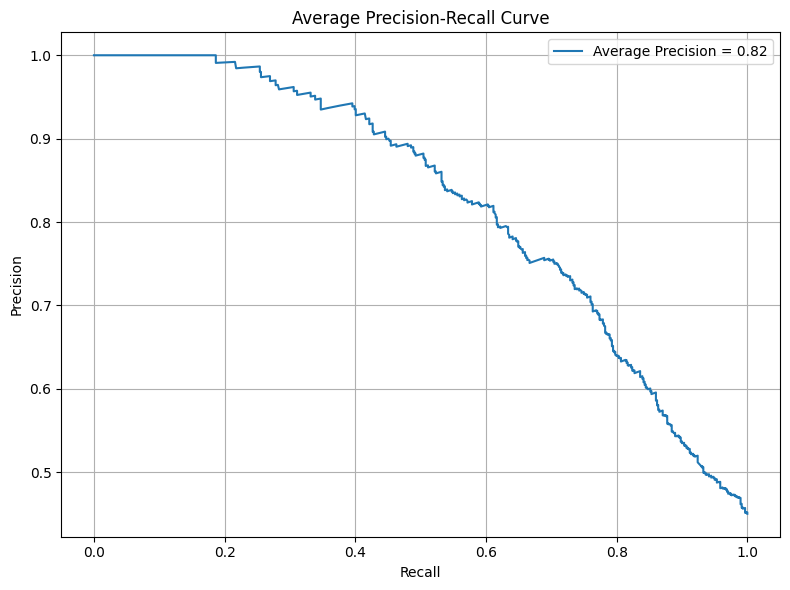

In [15]:
# Compute precision-recall curve and average precision
precision, recall, thresholds = precision_recall_curve(y_test, y_probas)
avg_precision = average_precision_score(y_test, y_probas)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'Average Precision = {avg_precision:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Average Precision-Recall Curve')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()